# 🧠 Hallucination Probes — sklearn + Neural Networks

Trains **13 probes** per layer across all `state_layer_*` columns and compares AUC-ROC.

### sklearn probes
| Group | Classifiers |
|---|---|
| Linear | LogisticRegression, RidgeClassifier, LinearSVC, Perceptron, SGD |
| Probabilistic | LDA, QDA, GaussianNB |
| Kernel / Distance | RBF-SVM, KNN |
| Ensemble | RandomForest, GradientBoosting, ExtraTrees |

### Neural probes (PyTorch, GPU)
| Architecture | What it tests |
|---|---|
| DeepLinear | Pure linear decomposability — no nonlinearity |
| Residual | Skip connections for high-dim states |
| Attention | Which feature chunks are diagnostic (interpretable weights) |
| Bottleneck | Minimum-dim manifold separating truth from hallucination |
| LayerNorm | Direction-only signal — magnitude stripped (zero-attractor test) |

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ─── 0. Install ───────────────────────────────────────────────────────────────
%%capture
!pip install -q scikit-learn matplotlib pandas torch

In [4]:
# ─── 1. CONFIG — only change this cell ───────────────────────────────────────
FILE_PATH      = "/content/drive/MyDrive/h_neuron_results/qwen3-4b_1iter_zeroed_response_states.pkl"
MODEL_NAME     = "qwen3-4b"
LABEL_KEY      = "hallucination_label"
CV_FOLDS       = 3      # 3-fold for N=100 → ~67 train / 33 test per fold
ENABLE_NEURAL  = True  # set True to also run the 5 PyTorch probes
EPOCHS         = 100     # neural only
BATCH_SIZE     = 16     # small batch for small N
LR             = 1e-3
OUTDIR         = "/content/drive/MyDrive/probe_results_H-neurons_mistral"
# ──────────────────────────────────────────────────────────────────────────────

In [5]:
# ─── 2. Imports ───────────────────────────────────────────────────────────────
import os, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# sklearn
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, Perceptron
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, accuracy_score, f1_score
from sklearn.pipeline import Pipeline

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
os.makedirs(OUTDIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [6]:
# ─── 3. Load data ─────────────────────────────────────────────────────────────
# Fix 1: pkl is a list of dicts → convert to DataFrame explicitly
raw_list = pd.read_pickle(FILE_PATH)
df_raw = pd.DataFrame(raw_list)

# Fix 2: saved keys are "state_0", "state_1", ... not "state_layer_N"
LAYER_COLS = sorted(
    [c for c in df_raw.columns if c.startswith("state_") and c[6:].isdigit()],
    key=lambda x: int(x.split("_")[-1])
)
LAYER_NUMS = [int(c.split("_")[-1]) for c in LAYER_COLS]
print(f"Loaded {len(df_raw)} total rows")
print(f"Layers: {LAYER_NUMS[0]} → {LAYER_NUMS[-1]}  ({len(LAYER_COLS)} total)")

# Fix 3: sample correctly (frac must be ≤ 1.0; use min to avoid oversampling)
df_raw = df_raw.groupby("original_label", group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), max(1, int(200 * len(x) / len(df_raw)))), random_state=42)
).reset_index(drop=True)
print(f"After sampling: {len(df_raw)} rows")

# ── Keep only rows that have BOTH a valid label AND a valid hidden state ──────
LABEL_KEY = "label"   # or "original_label" — whichever you want to probe against

def _is_valid(x):
    if x is None: return False
    if isinstance(x, float) and np.isnan(x): return False
    return True

mask = df_raw[LABEL_KEY].notna() & df_raw[LAYER_COLS[0]].apply(_is_valid)
df   = df_raw[mask].reset_index(drop=True)
print(f"Valid rows: {len(df)}  (dropped {len(df_raw)-len(df)})")
print(f"Label distribution:\n{df[LABEL_KEY].value_counts().to_string()}")

# ── Normalise tensors → numpy once ───────────────────────────────────────────
for lc in LAYER_COLS:
    df[lc] = df[lc].apply(lambda x: x.cpu().numpy() if hasattr(x, "cpu") else np.array(x))

HIDDEN_DIM = df[LAYER_COLS[0]].iloc[0].shape[0]
print(f"Hidden dim: {HIDDEN_DIM}")
y_all = df[LABEL_KEY].values.astype(np.float32)
print(f"y_all: {y_all.shape}  X per layer: ({len(df)}, {HIDDEN_DIM})  ✓ aligned")

Loaded 65 total rows
Layers: 0 → 35  (36 total)
After sampling: 65 rows
Valid rows: 65  (dropped 0)
Label distribution:
label
1    33
0    32
Hidden dim: 2560
y_all: (65,)  X per layer: (65, 2560)  ✓ aligned


In [7]:
# ─── 4a. sklearn probe definitions ───────────────────────────────────────────
# Each call to build_sklearn_classifiers() returns FRESH unfitted instances.
# This is called once per layer so probes never share fitted state across layers.
#
# Tuned for N=100 (~67 train per fold):
#   QDA removed     — covariance estimation unstable in high-dim small-N
#   Perceptron removed — too noisy to calibrate reliably at this size
#   KNN k=5          — stable with ~67 train samples
#   CalibratedCV=2   — avoids inner-fold collapse
#   GradBoosting     — shallow (max_depth=3) + fewer trees to limit overfit

def build_sklearn_classifiers():
    """Returns a dict of FRESH unfitted pipelines. Call once per layer."""
    def pipe(clf):
        return Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    def cal(clf):
        return Pipeline([("scaler", StandardScaler()),
                         ("clf", CalibratedClassifierCV(clf, cv=2, method="sigmoid"))])
    return {
        # ── Linear ───────────────────────────────────────────────────────────
        "LogisticReg":  pipe(LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs")),
        "Ridge":        cal(RidgeClassifier()),
        "LinearSVC":    cal(LinearSVC(max_iter=2000, C=1.0)),
        "SGD":          pipe(SGDClassifier(loss="modified_huber", max_iter=500, random_state=42)),
        # ── Probabilistic ────────────────────────────────────────────────────
        "LDA":          pipe(LinearDiscriminantAnalysis()),
        "GaussianNB":   pipe(GaussianNB()),
        # ── Kernel / Distance ────────────────────────────────────────────────
        "RBF-SVM":      pipe(SVC(kernel="rbf", probability=True, C=1.0)),
        "KNN":          pipe(KNeighborsClassifier(n_neighbors=5)),
        # ── Ensemble ─────────────────────────────────────────────────────────
        "RandomForest": pipe(RandomForestClassifier(n_estimators=100, random_state=42)),
        "GradBoosting": pipe(GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42)),
        "ExtraTrees":   pipe(ExtraTreesClassifier(n_estimators=100, random_state=42)),
    }

print(f"sklearn probes: {list(build_sklearn_classifiers().keys())}")

sklearn probes: ['LogisticReg', 'Ridge', 'LinearSVC', 'SGD', 'LDA', 'GaussianNB', 'RBF-SVM', 'KNN', 'RandomForest', 'GradBoosting', 'ExtraTrees']


In [8]:
# ─── 4b. Neural probe definitions ────────────────────────────────────────────

class DeepLinearProbe(nn.Module):
    """No nonlinearity — tests pure linear decomposability."""
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, d // 2), nn.Linear(d // 2, d // 4), nn.Linear(d // 4, 1)
        )
    def forward(self, x): return self.net(x).squeeze(-1)


class _ResBlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.block = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.Linear(d, d))
        self.norm  = nn.LayerNorm(d)
    def forward(self, x): return self.norm(x + self.block(x))

class ResidualProbe(nn.Module):
    """Skip connections — handles high-dim states (Llama 4096-dim)."""
    def __init__(self, d):
        super().__init__()
        self.proj   = nn.Linear(d, 256)
        self.blocks = nn.Sequential(_ResBlock(256), _ResBlock(256))
        self.head   = nn.Linear(256, 1)
    def forward(self, x): return self.head(self.blocks(self.proj(x))).squeeze(-1)


class AttentionProbe(nn.Module):
    """Self-attention over feature chunks — attention weights show which dims are diagnostic."""
    def __init__(self, d, chunk=64):
        super().__init__()
        self.chunk   = chunk
        self.n       = math.ceil(d / chunk)
        self.pad     = self.n * chunk - d
        self.attn    = nn.MultiheadAttention(chunk, num_heads=4, batch_first=True)
        self.norm    = nn.LayerNorm(chunk)
        self.head    = nn.Linear(chunk, 1)
    def forward(self, x):
        if self.pad: x = nn.functional.pad(x, (0, self.pad))
        x = x.view(x.size(0), self.n, self.chunk)
        out, _ = self.attn(x, x, x)
        return self.head(self.norm(out.mean(1))).squeeze(-1)


class BottleneckProbe(nn.Module):
    """Compress→expand: finds minimum-dim hallucination manifold."""
    def __init__(self, d, neck=8):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d, 128), nn.GELU(), nn.Linear(128, neck))
        self.dec = nn.Sequential(nn.Linear(neck, 64), nn.GELU(), nn.Linear(64, 1))
    def forward(self, x): return self.dec(self.enc(x)).squeeze(-1)


class LayerNormProbe(nn.Module):
    """LayerNorm first — strips magnitude, forces direction-only signal (zero-attractor test)."""
    def __init__(self, d):
        super().__init__()
        self.norm = nn.LayerNorm(d)
        self.net  = nn.Sequential(
            nn.Linear(d, 256), nn.GELU(), nn.Linear(256, 64), nn.GELU(), nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(self.norm(x)).squeeze(-1)


def get_neural_architectures(d):
    return {
        "NN-DeepLinear": lambda: DeepLinearProbe(d),
        "NN-Residual":   lambda: ResidualProbe(d),
        "NN-Attention":  lambda: AttentionProbe(d),
        "NN-Bottleneck": lambda: BottleneckProbe(d),
        "NN-LayerNorm":  lambda: LayerNormProbe(d),
    }

print(f"Neural probes: {list(get_neural_architectures(HIDDEN_DIM).keys())}")

Neural probes: ['NN-DeepLinear', 'NN-Residual', 'NN-Attention', 'NN-Bottleneck', 'NN-LayerNorm']


In [9]:
# ─── 5. Evaluation helpers ────────────────────────────────────────────────────

fprs_base = np.linspace(0, 1, 100)

def _pack_metrics(aucs, aps, accs, f1s, tprs):
    return {
        "auc_mean": np.mean(aucs), "auc_std": np.std(aucs),
        "ap_mean":  np.mean(aps),  "ap_std":  np.std(aps),
        "acc_mean": np.mean(accs), "acc_std": np.std(accs),
        "f1_mean":  np.mean(f1s),  "f1_std":  np.std(f1s),
        "mean_tpr": np.mean(tprs, axis=0),
        "std_tpr":  np.std(tprs,  axis=0),
        "fprs_base": fprs_base,
    }


# ── sklearn ───────────────────────────────────────────────────────────────────
# clone() gives a fresh unfitted copy of the pipeline for every fold,
# so each fold is fully independent even within a layer.
from sklearn.base import clone as sk_clone

def eval_sklearn_layer(X, y, classifiers, cv):
    results = {}
    for name, pipe in classifiers.items():
        aucs, aps, accs, f1s, tprs = [], [], [], [], []
        for tr, te in cv.split(X, y):
            try:
                fold_pipe = sk_clone(pipe)          # fresh unfitted copy per fold
                fold_pipe.fit(X[tr], y[tr])
                proba = (fold_pipe.predict_proba(X[te])[:, 1]
                         if hasattr(fold_pipe, "predict_proba")
                         else fold_pipe.decision_function(X[te]))
                preds = fold_pipe.predict(X[te])
                aucs.append(roc_auc_score(y[te], proba))
                aps.append(average_precision_score(y[te], proba))
                accs.append(accuracy_score(y[te], preds))
                f1s.append(f1_score(y[te], preds, zero_division=0))
                fpr, tpr, _ = roc_curve(y[te], proba)
                tprs.append(np.interp(fprs_base, fpr, tpr))
            except Exception as e:
                print(f"  ⚠ [{name}]: {e}")
        if aucs:
            results[name] = _pack_metrics(aucs, aps, accs, f1s, tprs)
    return results


# ── neural ────────────────────────────────────────────────────────────────────
# arch_fn() is a lambda that calls the constructor → brand new nn.Module every
# time, so neural probes are already fully isolated per fold and per layer.
def _train_one_neural(arch_fn, X_tr, y_tr, X_te, y_te):
    scaler = StandardScaler()
    X_tr_s = torch.tensor(scaler.fit_transform(X_tr), dtype=torch.float32)
    X_te_s = torch.tensor(scaler.transform(X_te),     dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)

    model = arch_fn().to(DEVICE)              # fresh model from random init
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    pos_w = torch.tensor([(y_tr == 0).sum() / max((y_tr == 1).sum(), 1)],
                          dtype=torch.float32).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    loader = DataLoader(TensorDataset(X_tr_s, y_tr_t),
                        batch_size=BATCH_SIZE, shuffle=True)

    best_auc, best_proba, patience, no_imp = 0, None, 8, 0
    for _ in range(EPOCHS):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            criterion(model(xb.to(DEVICE)), yb.to(DEVICE)).backward()
            opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            chunks = [torch.sigmoid(model(X_te_s[i:i+256].to(DEVICE))).cpu()
                      for i in range(0, len(X_te_s), 256)]
            proba = torch.cat(chunks).numpy()
        try:
            auc = roc_auc_score(y_te, proba)
        except Exception:
            auc = 0.5
        if auc > best_auc:
            best_auc, best_proba, no_imp = auc, proba.copy(), 0
        else:
            no_imp += 1
        if no_imp >= patience:
            break
    return best_proba


def eval_neural_layer(X, y, arch_fns, cv):
    results = {}
    for name, arch_fn in arch_fns.items():
        aucs, aps, accs, f1s, tprs = [], [], [], [], []
        for tr, te in cv.split(X, y):
            try:
                proba = _train_one_neural(arch_fn, X[tr], y[tr], X[te], y[te])
                preds = (proba >= 0.5).astype(int)
                aucs.append(roc_auc_score(y[te], proba))
                aps.append(average_precision_score(y[te], proba))
                accs.append(accuracy_score(y[te], preds))
                f1s.append(f1_score(y[te], preds, zero_division=0))
                fpr, tpr, _ = roc_curve(y[te], proba)
                tprs.append(np.interp(fprs_base, fpr, tpr))
            except Exception as e:
                print(f"  ⚠ [{name}]: {e}")
        if aucs:
            results[name] = _pack_metrics(aucs, aps, accs, f1s, tprs)
    return results

print("Evaluation helpers ready.")

Evaluation helpers ready.


In [10]:
# ─── 6. Main training loop ────────────────────────────────────────────────────
# Key design: build_sklearn_classifiers() is called INSIDE the layer loop so
# every layer gets its own fresh, unfitted probe instances.

cv           = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
all_results  = {}   # layer_col → {probe_name → metrics_dict}
summary_rows = []

n_sk = len(build_sklearn_classifiers())
n_nn = len(get_neural_architectures(HIDDEN_DIM)) if ENABLE_NEURAL else 0
n_tr = int(len(df) * (CV_FOLDS-1) / CV_FOLDS)
n_te = len(df) - n_tr
print(f"N={len(df)}  →  ~{n_tr} train / ~{n_te} test per fold  |  "
      f"{CV_FOLDS}-fold CV")
print(f"Probes per layer: {n_sk} sklearn"
      f"{f' + {n_nn} neural' if ENABLE_NEURAL else ' (neural disabled)'}")
print(f"Each layer gets its own fresh probe instances\n")

for i, lc in enumerate(LAYER_COLS):
    ln = int(lc.split("_")[-1])
    print(f"  Layer {ln:3d}  ({i+1}/{len(LAYER_COLS)})", end=" … ", flush=True)

    # Stack only the 100 valid rows — aligned with y_all
    X = np.vstack([v.mean(axis=0) for v in df[lc].values]).astype(np.float32)
    assert X.shape[0] == len(y_all), f"Shape mismatch: X={X.shape}, y={y_all.shape}"

    # Fresh probes for this layer
    sk_clfs = build_sklearn_classifiers()
    sk_res  = eval_sklearn_layer(X, y_all.astype(int), sk_clfs, cv)
    nn_res  = eval_neural_layer(X, y_all, get_neural_architectures(X.shape[1]), cv) \
              if ENABLE_NEURAL else {}

    layer_res = {**sk_res, **nn_res}
    all_results[lc] = layer_res

    best_name = max(layer_res, key=lambda k: layer_res[k]["auc_mean"])
    print(f"best AUC={layer_res[best_name]['auc_mean']:.3f} ({best_name})")

    for probe_name, m in layer_res.items():
        summary_rows.append({
            "layer": ln, "probe": probe_name,
            "auc_mean": m["auc_mean"], "auc_std":  m["auc_std"],
            "ap_mean":  m["ap_mean"],  "ap_std":   m["ap_std"],
            "acc_mean": m["acc_mean"], "f1_mean":  m["f1_mean"],
        })

summary_df = pd.DataFrame(summary_rows)
csv_path   = os.path.join(OUTDIR, f"{MODEL_NAME}_all_probes.csv")
summary_df.to_csv(csv_path, index=False)
print(f"\n✓ Saved CSV → {csv_path}")

N=65  →  ~43 train / ~22 test per fold  |  3-fold CV
Probes per layer: 11 sklearn + 5 neural
Each layer gets its own fresh probe instances

  Layer   0  (1/36) … best AUC=0.682 (NN-Attention)
  Layer   1  (2/36) … best AUC=0.556 (NN-Attention)
  Layer   2  (3/36) … best AUC=0.521 (NN-Attention)
  Layer   3  (4/36) … best AUC=0.686 (RBF-SVM)
  Layer   4  (5/36) … best AUC=0.606 (NN-Bottleneck)
  Layer   5  (6/36) … best AUC=0.703 (NN-Attention)
  Layer   6  (7/36) … best AUC=0.635 (NN-Residual)
  Layer   7  (8/36) … best AUC=0.677 (NN-Residual)
  Layer   8  (9/36) … best AUC=0.711 (NN-Attention)
  Layer   9  (10/36) … best AUC=0.715 (NN-Residual)
  Layer  10  (11/36) … best AUC=0.765 (NN-Attention)
  Layer  11  (12/36) … best AUC=0.761 (NN-Attention)
  Layer  12  (13/36) … best AUC=0.720 (NN-Residual)
  Layer  13  (14/36) … best AUC=0.740 (NN-Attention)
  Layer  14  (15/36) … best AUC=0.745 (NN-Residual)
  Layer  15  (16/36) … best AUC=0.709 (NN-Bottleneck)
  Layer  16  (17/36) … best A

In [11]:
# ─── 7. Colour palette ────────────────────────────────────────────────────────
# sklearn = muted blue family   neural = warm orange/red family

ALL_PROBES = list(next(iter(all_results.values())).keys())
SK_PROBES  = [p for p in ALL_PROBES if not p.startswith("NN-")]
NN_PROBES  = [p for p in ALL_PROBES if p.startswith("NN-")]

sk_colors  = cm.Blues(np.linspace(0.4, 0.9, len(SK_PROBES)))
nn_colors  = cm.Oranges(np.linspace(0.4, 0.9, len(NN_PROBES)))
COLORS     = {p: c for p, c in zip(SK_PROBES, sk_colors)}
COLORS.update({p: c for p, c in zip(NN_PROBES, nn_colors)})

print(f"sklearn probes ({len(SK_PROBES)}): {SK_PROBES}")
print(f"Neural  probes ({len(NN_PROBES)}): {NN_PROBES}")

sklearn probes (11): ['LogisticReg', 'Ridge', 'LinearSVC', 'SGD', 'LDA', 'GaussianNB', 'RBF-SVM', 'KNN', 'RandomForest', 'GradBoosting', 'ExtraTrees']
Neural  probes (5): ['NN-DeepLinear', 'NN-Residual', 'NN-Attention', 'NN-Bottleneck', 'NN-LayerNorm']


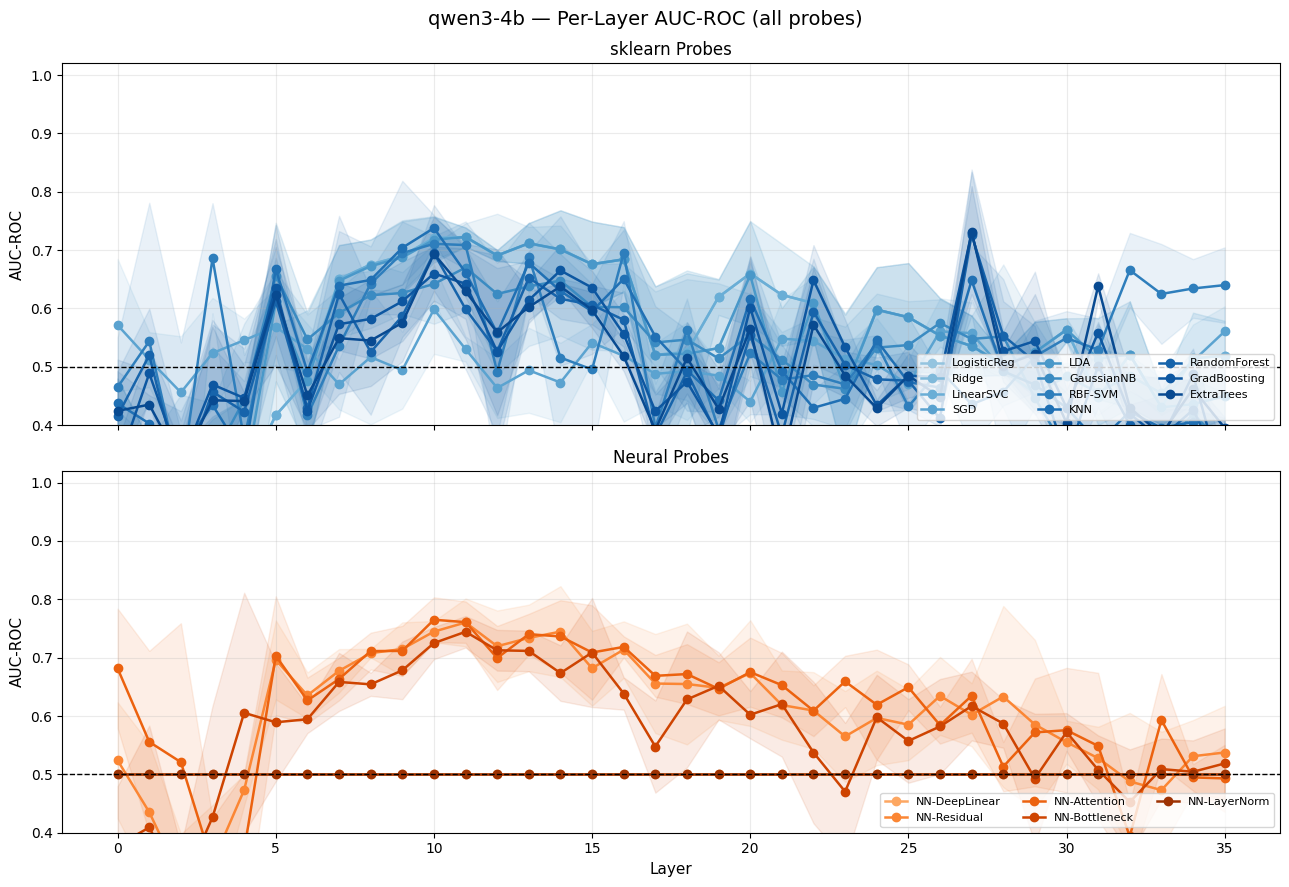

Saved: /content/drive/MyDrive/probe_results_H-neurons/qwen3-4b_auc_curves.png


In [12]:
# ─── 8. Plot 1: AUC curves by layer (split panels) ───────────────────────────

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

for ax, probe_group, title in [
    (ax1, SK_PROBES, "sklearn Probes"),
    (ax2, NN_PROBES, "Neural Probes"),
]:
    for probe in probe_group:
        aucs = [all_results[lc][probe]["auc_mean"] for lc in LAYER_COLS]
        stds = [all_results[lc][probe]["auc_std"]  for lc in LAYER_COLS]
        c    = COLORS[probe]
        ax.plot(LAYER_NUMS, aucs, marker="o", label=probe, color=c, linewidth=1.8)
        ax.fill_between(LAYER_NUMS,
                        np.array(aucs)-np.array(stds),
                        np.array(aucs)+np.array(stds),
                        alpha=0.1, color=c)
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_ylabel("AUC-ROC", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0.4, 1.02)
    ax.legend(ncol=3, fontsize=8, loc="lower right")
    ax.grid(True, alpha=0.25)

ax2.set_xlabel("Layer", fontsize=11)
fig.suptitle(f"{MODEL_NAME} — Per-Layer AUC-ROC (all probes)", fontsize=14)
plt.tight_layout()
p = os.path.join(OUTDIR, f"{MODEL_NAME}_auc_curves.png")
fig.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

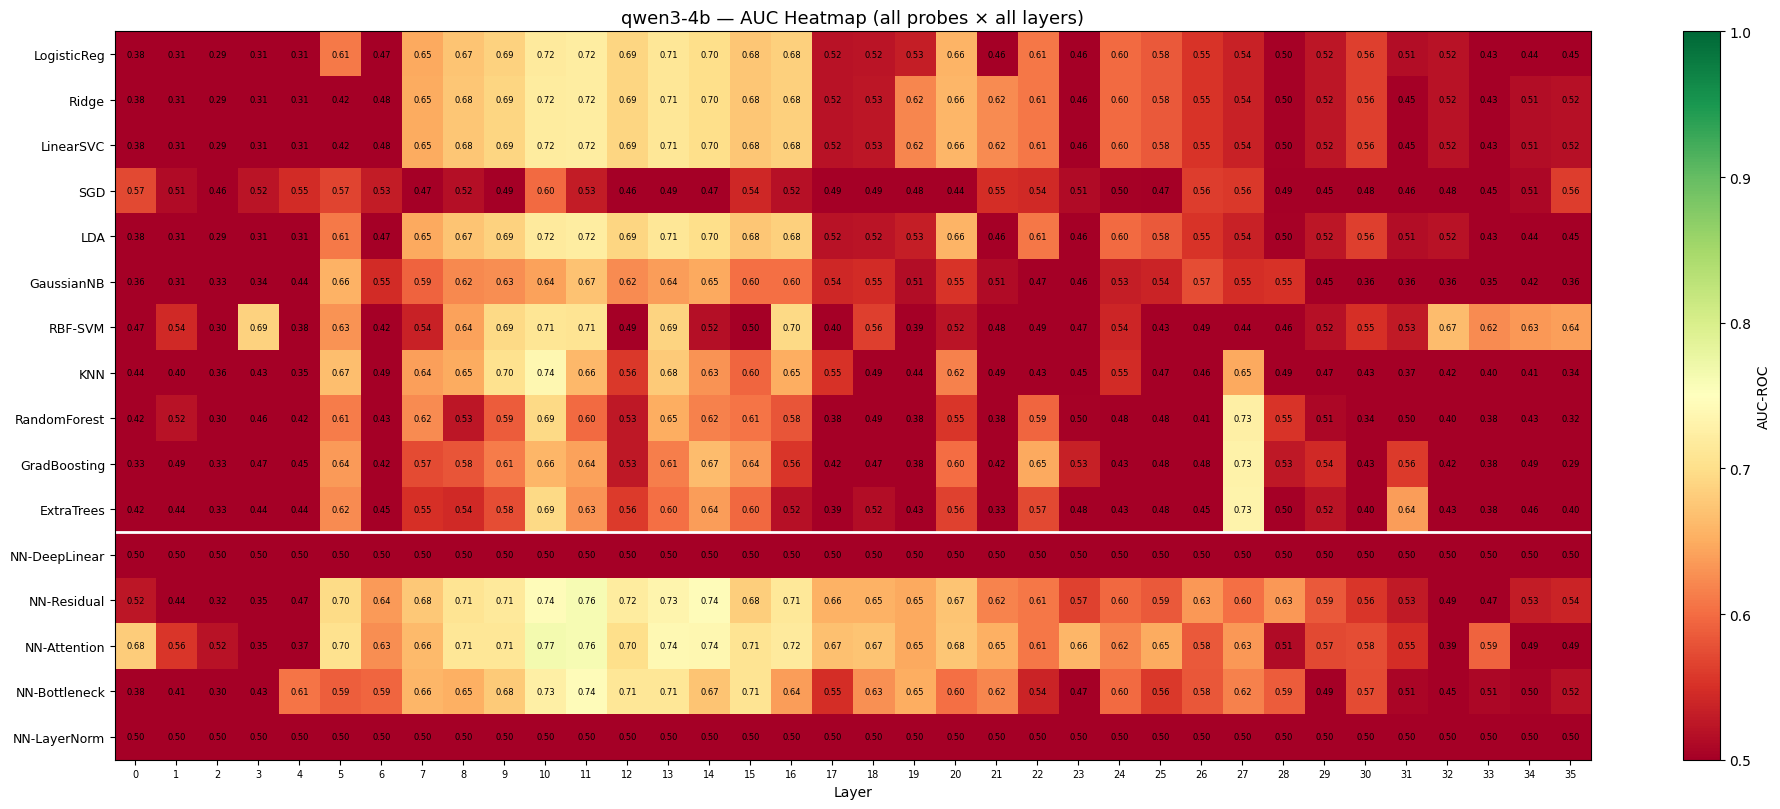

Saved: /content/drive/MyDrive/probe_results_H-neurons/qwen3-4b_heatmap.png


In [13]:
# ─── 9. Plot 2: Heatmap — all probes × all layers ─────────────────────────────

data = np.array([[all_results[lc][p]["auc_mean"] for lc in LAYER_COLS]
                  for p in ALL_PROBES])

fig, ax = plt.subplots(figsize=(max(12, len(LAYER_COLS)*0.55), len(ALL_PROBES)*0.45 + 1))
im = ax.imshow(data, aspect="auto", cmap="RdYlGn", vmin=0.5, vmax=1.0)
plt.colorbar(im, ax=ax, label="AUC-ROC")
ax.set_xticks(range(len(LAYER_COLS))); ax.set_xticklabels(LAYER_NUMS, fontsize=7)
ax.set_yticks(range(len(ALL_PROBES))); ax.set_yticklabels(ALL_PROBES, fontsize=9)

# Divider between sklearn and neural
ax.axhline(len(SK_PROBES) - 0.5, color="white", linewidth=2)

for i in range(len(ALL_PROBES)):
    for j in range(len(LAYER_COLS)):
        ax.text(j, i, f"{data[i,j]:.2f}", ha="center", va="center", fontsize=6)

ax.set_xlabel("Layer")
ax.set_title(f"{MODEL_NAME} — AUC Heatmap (all probes × all layers)", fontsize=13)
plt.tight_layout()
p = os.path.join(OUTDIR, f"{MODEL_NAME}_heatmap.png")
fig.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

Best layer: 10


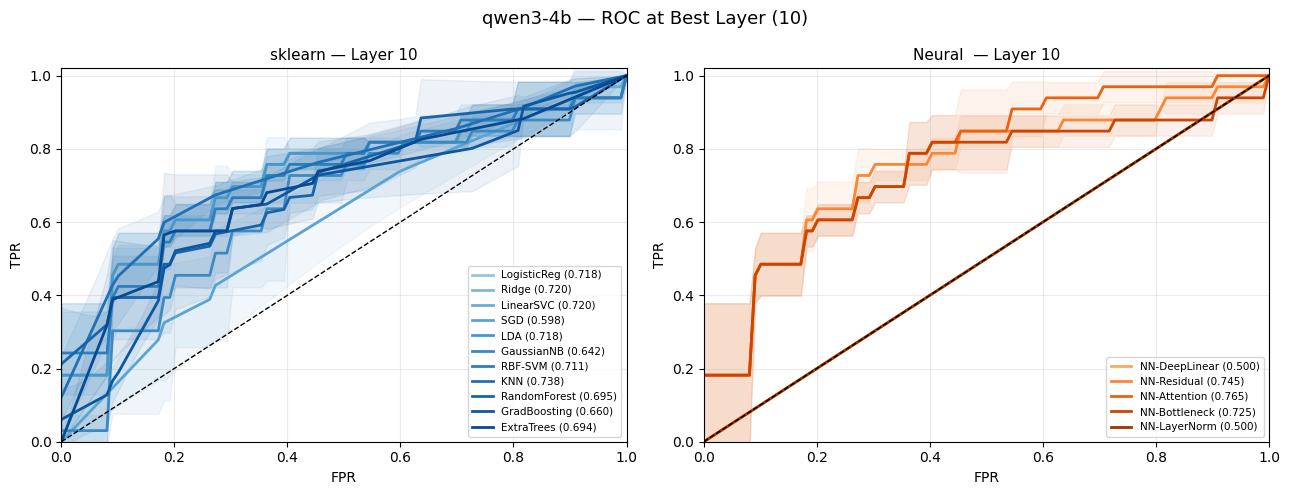

Saved: /content/drive/MyDrive/probe_results_H-neurons/qwen3-4b_roc_best_layer.png


In [14]:
# ─── 10. Plot 3: ROC at best layer ────────────────────────────────────────────

best_lc = max(LAYER_COLS,
              key=lambda lc: max(all_results[lc][p]["auc_mean"] for p in ALL_PROBES))
best_ln = int(best_lc.split("_")[-1])
print(f"Best layer: {best_ln}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, probe_group, title in [
    (ax1, SK_PROBES, f"sklearn — Layer {best_ln}"),
    (ax2, NN_PROBES, f"Neural  — Layer {best_ln}"),
]:
    for probe in probe_group:
        r   = all_results[best_lc][probe]
        c   = COLORS[probe]
        lbl = f"{probe} ({r['auc_mean']:.3f})"
        ax.plot(r["fprs_base"], r["mean_tpr"], color=c, linewidth=2, label=lbl)
        ax.fill_between(r["fprs_base"],
                        r["mean_tpr"]-r["std_tpr"],
                        r["mean_tpr"]+r["std_tpr"],
                        alpha=0.08, color=c)
    ax.plot([0,1],[0,1],"k--",linewidth=1)
    ax.set_xlim(0,1); ax.set_ylim(0,1.02)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=7.5, loc="lower right")
    ax.grid(alpha=0.25)

fig.suptitle(f"{MODEL_NAME} — ROC at Best Layer ({best_ln})", fontsize=13)
plt.tight_layout()
p = os.path.join(OUTDIR, f"{MODEL_NAME}_roc_best_layer.png")
fig.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

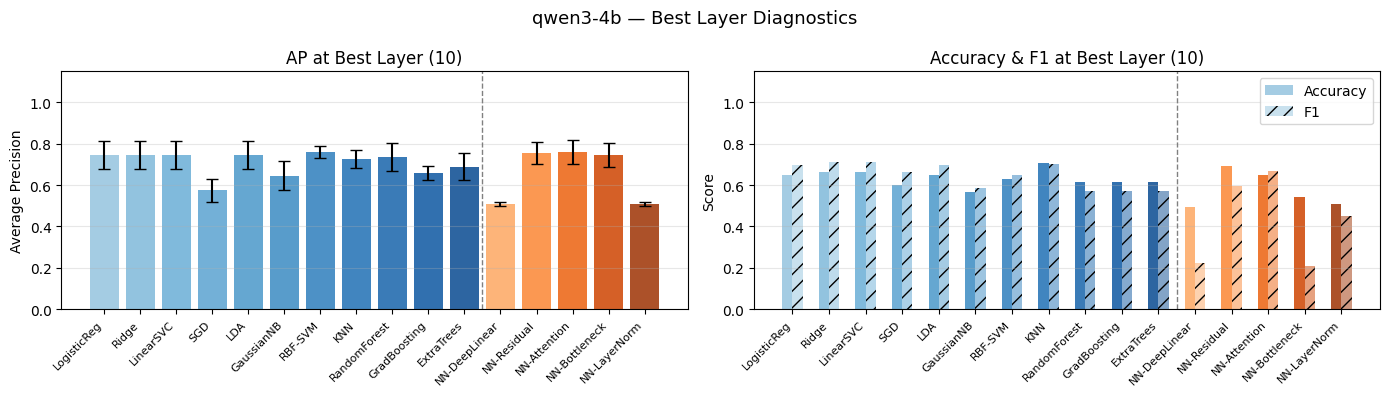

Saved: /content/drive/MyDrive/probe_results_H-neurons/qwen3-4b_best_layer_metrics.png


In [15]:
# ─── 11. Plot 4: AP + F1 bar chart at best layer ─────────────────────────────

r      = all_results[best_lc]
probes = ALL_PROBES
x      = np.arange(len(probes))
w      = 0.28
colors = [COLORS[p] for p in probes]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# AP
axes[0].bar(x, [r[p]["ap_mean"] for p in probes],
            yerr=[r[p]["ap_std"] for p in probes],
            color=colors, alpha=0.85, capsize=4)
axes[0].set_xticks(x); axes[0].set_xticklabels(probes, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Average Precision")
axes[0].set_title(f"AP at Best Layer ({best_ln})")
axes[0].set_ylim(0, 1.15); axes[0].grid(axis="y", alpha=0.3)
axes[0].axvline(len(SK_PROBES) - 0.5, color="gray", linestyle="--", linewidth=1)

# Acc + F1
axes[1].bar(x - w/2, [r[p]["acc_mean"] for p in probes], w,
            color=colors, alpha=0.85, label="Accuracy")
axes[1].bar(x + w/2, [r[p]["f1_mean"]  for p in probes], w,
            color=colors, alpha=0.5,  label="F1", hatch="//")
axes[1].set_xticks(x); axes[1].set_xticklabels(probes, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Score")
axes[1].set_title(f"Accuracy & F1 at Best Layer ({best_ln})")
axes[1].set_ylim(0, 1.15); axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
axes[1].axvline(len(SK_PROBES) - 0.5, color="gray", linestyle="--", linewidth=1)

fig.suptitle(f"{MODEL_NAME} — Best Layer Diagnostics", fontsize=13)
plt.tight_layout()
p = os.path.join(OUTDIR, f"{MODEL_NAME}_best_layer_metrics.png")
fig.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

In [16]:
# ─── 12. Summary tables ───────────────────────────────────────────────────────

print(f"\n{'='*65}")
print(f"  {MODEL_NAME} — Top 10 (probe, layer) by AUC")
print(f"{'='*65}")
print(summary_df.nlargest(10, "auc_mean")[["probe","layer","auc_mean","auc_std","ap_mean","f1_mean"]]
      .to_string(index=False))

print(f"\n{'─'*65}")
print("  Best AUC per probe (peak layer)")
print(f"{'─'*65}")
best_per = summary_df.loc[summary_df.groupby("probe")["auc_mean"].idxmax()]
print(best_per[["probe","layer","auc_mean","auc_std","ap_mean","f1_mean"]]
      .sort_values("auc_mean", ascending=False).to_string(index=False))

print(f"\n✓ All outputs saved to: {OUTDIR}")


  qwen3-4b — Top 10 (probe, layer) by AUC
        probe  layer  auc_mean  auc_std  ap_mean  f1_mean
 NN-Attention     10  0.765014 0.038388 0.760404 0.667440
 NN-Attention     11  0.760882 0.035459 0.771774 0.677980
  NN-Residual     11  0.760331 0.041046 0.772791 0.678363
  NN-Residual     10  0.744628 0.018269 0.756090 0.596767
  NN-Residual     14  0.744628 0.077917 0.779188 0.679365
NN-Bottleneck     11  0.744353 0.027003 0.763981 0.055556
 NN-Attention     13  0.740220 0.034909 0.787103 0.685455
          KNN     10  0.737741 0.022035 0.726604 0.701170
 NN-Attention     14  0.736364 0.062077 0.770770 0.655694
  NN-Residual     13  0.733884 0.056987 0.788679 0.578788

─────────────────────────────────────────────────────────────────
  Best AUC per probe (peak layer)
─────────────────────────────────────────────────────────────────
        probe  layer  auc_mean  auc_std  ap_mean  f1_mean
 NN-Attention     10  0.765014 0.038388 0.760404 0.667440
  NN-Residual     11  0.760331 0.041

In [17]:
import shutil, os

src = "/content/"
dst = "/content/drive/MyDrive/probe_results_H-neurons"
os.makedirs(dst, exist_ok=True)

added = 0
for fname in os.listdir(src):
    dst_file = os.path.join(dst, fname)
    if not os.path.exists(dst_file):
        shutil.copy2(os.path.join(src, fname), dst_file)
        added += 1

print(f"Done! Added {added} new file(s), skipped {len(os.listdir(src)) - added} existing.")

IsADirectoryError: [Errno 21] Is a directory: '/content/.config'